In [16]:
# Import libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Connect to biocomplexity.duckdb database
conn = duckdb.connect("/Users/austinmartinez/Documents/MEDS/EDS-213/eds213-salmon_database/database/biocomplexity.duckdb")

# Print tables in database
conn.execute("SHOW TABLES").df()

,name
0,diet
1,predator_fish
2,prey_crayfish
3,prey_fish


In [ ]:
# Run SQL query and assign output to result
# Find how many crayfish and fish SMB(Smallmouth bass) and RB(Rock bass) eat
# Use diet, prey_fish, and prey_crayfish tables
result = conn.execute("""
SELECT
    diet.species,
    SUM(prey_fish.count) AS total_fish_items,
    SUM(prey_crayfish.count) AS total_crayfish_items
FROM diet
LEFT JOIN prey_fish
    ON diet.gutlabel = prey_fish.gutlabel
LEFT JOIN prey_crayfish
    ON diet.gutlabel = prey_crayfish.gutlabel
WHERE diet.species IN ('SMB', 'RB')
GROUP BY diet.species
ORDER BY diet.species;
""").df()

# Print results
print(result)

  species  total_fish_items  total_crayfish_items
0      RB             264.0                  30.0
1     SMB             682.0                 822.0


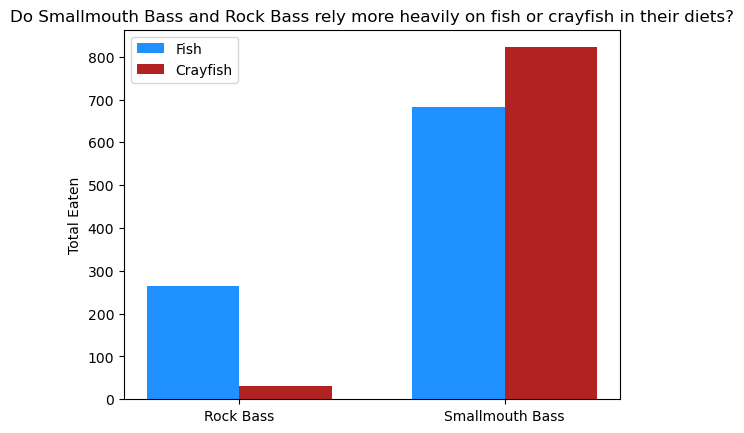

In [ ]:
# Rename SMB and RB in species column to Smallmouth Bass and Rock Bass for clarity when plotting
result.loc[result['species'] == 'SMB', 'species'] = 'Smallmouth Bass'
result.loc[result['species'] == 'RB',  'species'] = 'Rock Bass'

# Set the positions for the bars
x = np.arange(len(result))

# Set the bar width
width = 0.35

# Plot blue bar showing how many fish were eaten
plt.bar(x - width/2, result['total_fish_items'], width, color='dodgerblue', label='Fish')
# Plot red bar showing how many crayfish were eaten
plt.bar(x + width/2, result['total_crayfish_items'], width, color='firebrick', label='Crayfish')

# set x‑axis and y-axis labels to species names
plt.xticks(x, result['species'])
plt.ylabel("Total Eaten")
plt.title("Do Smallmouth Bass and Rock Bass rely more heavily on fish or crayfish in their diets?")
plt.legend()
plt.show()

In [11]:
# Close Database
conn.close()